# 00 — Data Exploration

Loads a file from each of the two source datasets (CWRU bearing vibration signals, NASA C-MAPSS turbofan degradation) and plots a few signals to confirm shapes and sampling rates.

See [docs/datasets.md](../docs/datasets.md) for the full write-up of what's in `data/raw/`.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat

DATA_RAW = Path.cwd().parent / "data" / "raw"
CWRU_DIR = DATA_RAW / "cwru"
CMAPSS_DIR = DATA_RAW / "cmapss"

## CWRU Bearing Dataset

12,000 samples/second. Each `.mat` file holds drive-end (`_DE_time`) and fan-end (`_FE_time`) accelerometer channels, a base channel (`_BA_time`) on fault files, and motor RPM.

In [2]:
SAMPLE_RATE_HZ = 12_000

normal = loadmat(CWRU_DIR / "Normal_0.mat")
inner_race = loadmat(CWRU_DIR / "IR007_0.mat")

print("Normal_0 keys:", [k for k in normal if not k.startswith("__")])
print("IR007_0 keys:", [k for k in inner_race if not k.startswith("__")])

Normal_0 keys: ['X097_DE_time', 'X097_FE_time', 'X097RPM']
IR007_0 keys: ['X105_DE_time', 'X105_FE_time', 'X105_BA_time', 'X105RPM']


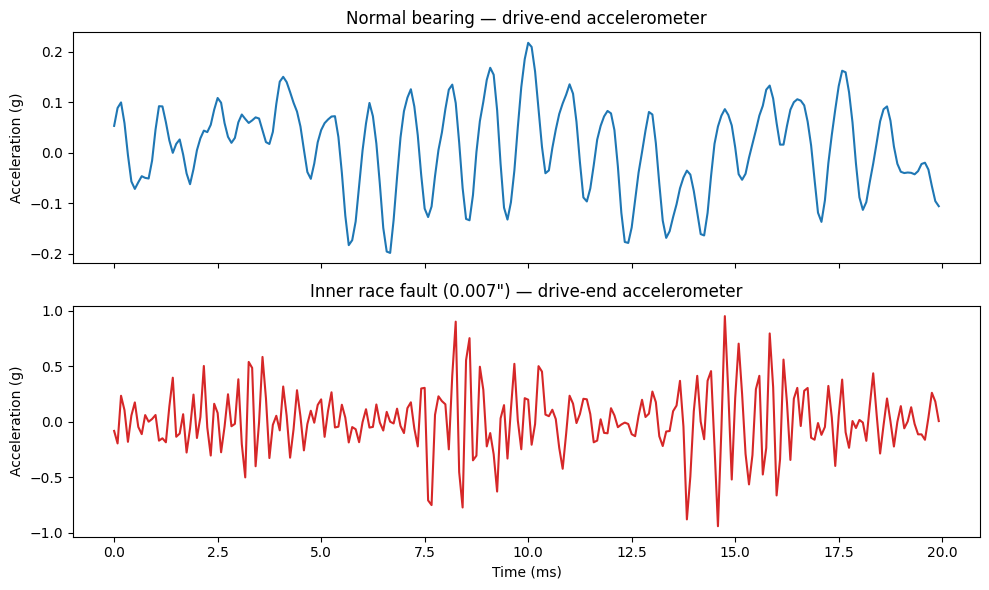

In [3]:
normal_de = normal["X097_DE_time"].ravel()
fault_de = inner_race["X105_DE_time"].ravel()

n_samples = int(0.02 * SAMPLE_RATE_HZ)  # 20 ms window
t = np.arange(n_samples) / SAMPLE_RATE_HZ * 1000  # ms

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t, normal_de[:n_samples])
axes[0].set_title("Normal bearing — drive-end accelerometer")
axes[0].set_ylabel("Acceleration (g)")

axes[1].plot(t, fault_de[:n_samples], color="tab:red")
axes[1].set_title("Inner race fault (0.007\") — drive-end accelerometer")
axes[1].set_ylabel("Acceleration (g)")
axes[1].set_xlabel("Time (ms)")

fig.tight_layout()
plt.show()

## NASA C-MAPSS

FD001 subset: 100 train units, single operating condition, single fault mode (HPC degradation). Columns: `unit_id`, `cycle`, 3 operational settings, 21 sensor channels.

In [4]:
cols = (
    ["unit_id", "cycle"]
    + [f"op_setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)
df = pd.read_csv(CMAPSS_DIR / "train_FD001.txt", sep=r"\s+", header=None, names=cols)
print("shape:", df.shape, "| units:", df["unit_id"].nunique())
df.head()

shape: (20631, 26) | units: 100


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


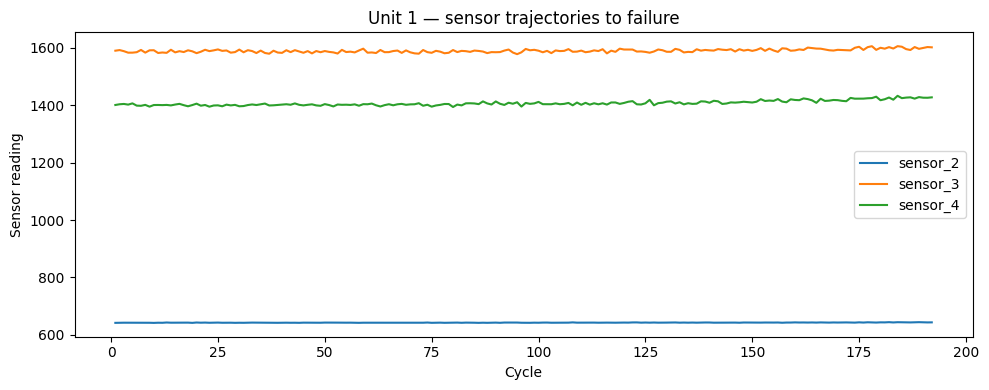

In [5]:
unit_1 = df[df["unit_id"] == 1]

fig, ax = plt.subplots(figsize=(10, 4))
for sensor in ["sensor_2", "sensor_3", "sensor_4"]:
    ax.plot(unit_1["cycle"], unit_1[sensor], label=sensor)
ax.set_title("Unit 1 — sensor trajectories to failure")
ax.set_xlabel("Cycle")
ax.set_ylabel("Sensor reading")
ax.legend()
fig.tight_layout()
plt.show()